In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Figure size 1600x500 with 0 Axes>

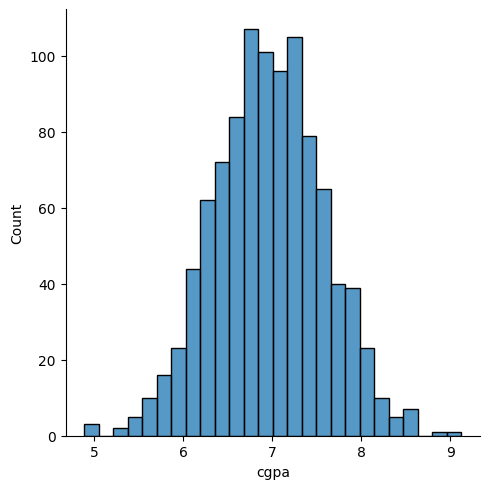

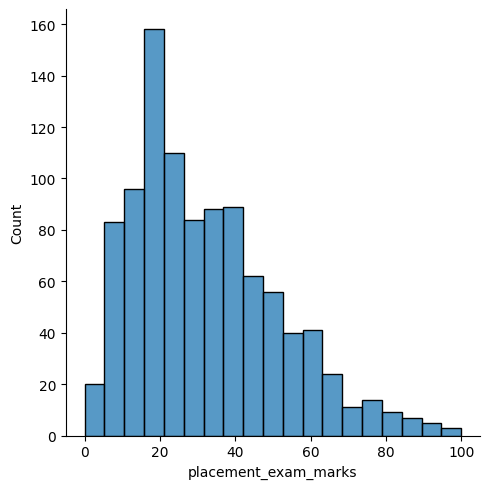

In [3]:
plt.figure(figsize=(16,5))
sns.displot(df['cgpa'])
sns.displot(df['placement_exam_marks'])
plt.show()

In [4]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [5]:
#finding boundary values

print("Highest allowed : " , df['cgpa'].mean()+3*df['cgpa'].std())
print("Lowest allowed : " , df['cgpa'].mean()-3*df['cgpa'].std())

Highest allowed :  8.808933625397168
Lowest allowed :  5.113546374602832


In [6]:
#finding outliers
df[(df['cgpa']>8.80 )| (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [7]:
#trimming
#df = df[(df['cgpa']<8.80 ) &  (df['cgpa']>5.11)]
df.shape


(1000, 3)

In [8]:
#calc the z score(second approach)

In [9]:
df['zscore'] = (df['cgpa'] - df['cgpa'].mean() )/ df['cgpa'].std()
df.head()

,cgpa,placement_exam_marks,placed,zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [10]:
#df = df[(df['zscore']<3) & (df['zscore']>-3)]
df.shape


(1000, 4)

In [11]:
#capping

upperLimit =  df['cgpa'].mean()+3*df['cgpa'].std()
lowerLimit = df['cgpa'].mean()-3*df['cgpa'].std()
df['cgpa'] = np.where(
    df['cgpa'] > upperLimit,
    upperLimit,
    np.where(
        df['cgpa']<lowerLimit,
        lowerLimit,
        df['cgpa']
    )
)

df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64